In [1]:
import math
from collections import deque
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

In [12]:
# # # # # # # How to Use:
#  m: total number of edges in the graph
#  B: the largest label assigned in the graph
#  used_sums: the weights (sums) of the edges
#   ---- ----- ---- ----
#   This function works well for Problem 1 and Problem 2.
#   To check Problem 1, try this:
#     m, labels, B, used_sums = Branch_Bound(5, 1)  # 5 is the number of columns, and 1 defines the Mongolian tent graph
#   To check Problem 2, try this:
#     m, labels, B, used_sums = Branch_Bound(1, 2)  # 1 is the number of stars, and 2 defines the star graph
# Make sure to import the required libraries.


m,labels, B, used_sums = Branch_Bound(7, 1)

Order: ['z', 'v1_1', 'v1_2', 'v1_3', 'v1_4', 'v1_5', 'v1_6', 'v1_7', 'v2_1', 'v2_2', 'v2_3', 'v2_4', 'v2_5', 'v2_6', 'v2_7', 'v3_1', 'v3_2', 'v3_3', 'v3_4', 'v3_5', 'v3_6', 'v3_7']
Optimal B: 20
Labels: {'z': 1, 'v1_1': 2, 'v1_2': 3, 'v2_1': 11, 'v1_3': 5, 'v2_2': 13, 'v1_4': 6, 'v2_3': 20, 'v1_5': 8, 'v2_4': 17, 'v1_6': 9, 'v2_5': 14, 'v1_7': 11, 'v2_6': 20, 'v2_7': 15, 'v3_1': 17, 'v3_2': 19, 'v3_3': 20, 'v3_4': 1, 'v3_5': 1, 'v3_6': 18, 'v3_7': 12}
Used sums: {3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 27, 17, 2, 20, 28, 31, 15, 26, 16, 18, 29, 19, 30, 21, 22, 23, 24, 25, 38, 39, 40, 35, 36, 37, 32, 33, 34}
duplicates: 0


In [3]:
def Branch_Bound(n, graph_type = 1):
  if graph_type == 1:
    adj = generate_Mongolian_Graph(n)
    m,labels, B, used_sums = solve_min_B(adj, source='z')
  elif graph_type == 2:
    adj = generate_Star_Graph(n)
    m,labels, B, used_sums = solve_min_B(adj, source= 1)
  print("Optimal B:", B)
  print("Labels:", labels)
  print("Used sums:", used_sums)

  def check_labeling(adj, labels):
      used = {}
      dup = []
      for u, nbrs in adj.items():
          for v in nbrs:
              if u < v:
                  s = labels[u] + labels[v]
                  if s in used:
                      dup.append(((u,v), s, used[s]))
                  else:
                      used[s] = (u,v)
      return dup

  dups = check_labeling(adj, labels)
  print("duplicates:", len(dups))
  return m,labels, B, used_sums

In [4]:
def edges_from_adj(adj):
    E = set()
    for u, nbrs in adj.items():
        for v in nbrs:
            if u < v:
                E.add((u, v))
    return sorted(E)

def bfs_order(adj, source):
    q = deque([source])
    seen = {source}
    order = []
    while q:
        u = q.popleft()
        order.append(u)
        for v in adj[u]:
            if v not in seen:
                seen.add(v)
                q.append(v)
    # if the graph is not connected, add the remaining vertices
    for v in adj.keys():
        if v not in seen:
            order.append(v)
    return order

def feasible_with_B(adj, B, source=1):
    # Return (labels, used_sums) if feasible with maximum label B, otherwise None.
    edges = edges_from_adj(adj)
    m = len(edges)

    order = bfs_order(adj, source)
    print("Order:", order)
    label = {v: None for v in adj.keys()}
    label[source] = 1  # symmetry breaking
    used_sums = set()  # each element is the sum of labels of one edge

    def dfs(pos):
         # prune by remaining sum capacity: there are (2B-1) - len(used_sums) “slots” left for sums,
        # if the remaining number of edges is larger, it's guaranteed to fail
        remaining_edges = m - len(used_sums)
        remaining_slots  = (2*B - 1) - len(used_sums)
        if remaining_edges > remaining_slots:
            return False

        if pos == len(order):
            return True

        v = order[pos]
        if v == source:
            return dfs(pos + 1)

       # try labels from 1..B (prefer smaller ones first)
        for val in range(1, B+1):
             # positive labels, within range; keep source=1
            added = []
            local = set()   #avoid duplicate sums within this step
            ok = True
            for w in adj[v]:
                lw = label.get(w)
                if lw is None:
                    continue
                s = val + lw
                if s in used_sums or s in local:
                    ok = False
                    break
                local.add(s)
                added.append(s)
            if not ok:
                continue

            # commit
            label[v] = val
            for s in added:
                used_sums.add(s)

            if dfs(pos + 1):
                return True

            # undo
            for s in added:
                used_sums.remove(s)
            label[v] = None

        return False
    return (label, used_sums) if dfs(0) else None

def solve_min_B(adj, source=1):
    # Minimize the maximum label B (label ∈ [1..B]) and ensure all edge sums are unique.
    m = len(edges_from_adj(adj))
    LB = math.ceil((m + 1)/2)  # lower bound required from counting sums
    B = LB
    while True:
        res = feasible_with_B(adj, B, source=source)
        if res is not None:
            labels, used_sums = res
            return m,labels, B, used_sums
        B += 1


In [60]:
## Calculating upper, lower bound and max k of the algorithms
length = 10
lower_bound = []
upper_bound = []
algorithms = []
for i in range(1, length):
    edge,labels,B,_ = Branch_Bound(i, 2) #Be sure to check if you choose correct graph and length?
    v = len(labels)
    lower_bound.append((edge+1)/2)
    upper_bound.append(edge * np.log2(v))
    algorithms.append(B)


Order: [1, 2, 3, 7, 8, 10, 6, 4, 5, 9]
Optimal B: 8
Labels: {1: 1, 2: 1, 3: 2, 7: 4, 8: 5, 10: 7, 6: 2, 4: 8, 5: 8, 9: 7}
Used sums: {2, 3, 14, 11, 9, 5, 6, 7, 8, 13, 10, 12, 16, 15, 4}
duplicates: 0
Order: [1, 2, 3, 7, 8, 10, 6, 4, 5, 9, 11, 12, 16, 17, 19, 15, 13, 14, 18]
Optimal B: 16
Labels: {1: 1, 2: 1, 3: 2, 7: 3, 8: 4, 10: 5, 6: 6, 4: 7, 5: 10, 9: 16, 11: 2, 12: 10, 16: 15, 17: 14, 19: 16, 15: 14, 13: 13, 14: 12, 18: 16}
Used sums: {2, 3, 4, 5, 6, 8, 9, 10, 12, 13, 14, 27, 17, 28, 26, 15, 16, 29, 18, 19, 20, 21, 22, 23, 24, 25, 32, 31, 30, 7}
duplicates: 0
Order: [1, 2, 3, 7, 8, 10, 6, 4, 5, 9, 11, 12, 16, 17, 19, 15, 13, 14, 18, 20, 21, 25, 26, 28, 24, 22, 23, 27]
Optimal B: 23
Labels: {1: 1, 2: 1, 3: 2, 7: 3, 8: 4, 10: 5, 6: 6, 4: 7, 5: 10, 9: 13, 11: 2, 12: 6, 16: 10, 17: 18, 19: 19, 15: 16, 13: 17, 14: 14, 18: 19, 20: 7, 21: 11, 25: 23, 26: 18, 28: 21, 24: 22, 22: 16, 23: 23, 27: 22}
Used sums: {2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 

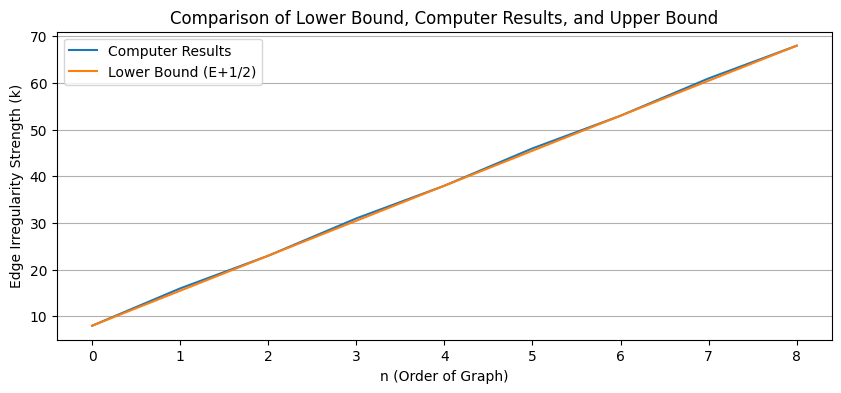

In [65]:
plt.figure(figsize=(10,4))
plt.plot(algorithms, label = 'Computer Results')
plt.plot(lower_bound, label = 'Lower Bound (E+1/2)')
# plt.plot(upper_bound, label = 'Upper Bound (Elog2V)')
plt.xlabel('n (Order of Graph)')
plt.ylabel('Edge Irregularity Strength (k)')
plt.title('Comparison of Lower Bound, Computer Results, and Upper Bound')
plt.grid(axis= 'y')
plt.legend()

In [6]:
def generate_Mongolian_Graph(n):
    A = []
    adj = defaultdict(list)
    for i in range(1,4):
        for j in range(1,n+1):
            # Checking if I should add z in the lasted
            if i == 1:
                A.append(('z', f'v{i}_{j}'))
            if j != n:
                A.append((f'v{i}_{j}', f'v{i}_{j+1}'))
            if i != 3:
                A.append((f'v{i}_{j}', f'v{i+1}_{j}'))
    for u,v in A:
      adj[u].append(v)
      adj[v].append(u)

    return adj

In [8]:
def generate_Star_Graph(n):
  A = [[1,2], [1,3],[1,7], [2,8], [2,10], [3,6], [3,4], [4,10],[4,5], [5,7],[5,8],[6,9],[6,8],[7,9],[9,10]] #Edges for Problem 2
  adj = defaultdict(list)
  for i in range(0,n):
      for u,v in A:
          u += i*9
          v += i*9
          adj[u].append(v)
          adj[v].append(u)
  return adj